### Purpose

This notebook ingests and prepares Fingertips health indicators for North West London boroughs and validates deprivation as a key axis of health inequality.

Building on indicator selection in Notebook 01, it converts shortlisted Fingertips indicators into analysis-ready data and conducts focused exploratory analysis to confirm the presence and consistency of deprivation gradients across boroughs.

### Role in the project

Fingertips provides the core empirical evidence for this project. This notebook establishes which indicators reliably reflect structural inequality in North West London and are therefore suitable for later ethnicity-focused analysis.

### Scope

- Ingest and clean selected Fingertips indicators

- Restrict data to the eight North West London boroughs

- Standardise borough naming

- Explore deprivation-stratified patterns for selected indicators

- Persist clean data for downstream analysis

This notebook performs validation and exploration, not causal or ethnicity analysis.

In [1]:
from pathlib import Path
import importlib.util

import pandas as pd
import requests

HERE = Path.cwd()

def has_module(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

PARQUET_ENGINE = "pyarrow" if has_module("pyarrow") else "fastparquet"
print("Parquet engine:", PARQUET_ENGINE)

SHORTLIST_FILE = "_shortlist_fingertips_candidates.csv"
BOROUGHS_FILE = "_config_nwl_boroughs.csv"          
ETH_MAP_FILE = "_config_ethnicity_mapping.csv"      

shortlist = pd.read_csv(HERE / SHORTLIST_FILE)
if "keep" in shortlist.columns:
    shortlist = shortlist[shortlist["keep"] == True].copy()
boroughs = pd.read_csv(HERE / BOROUGHS_FILE)

nwl_borough_set = set(boroughs["borough"].astype(str))

BOROUGH_ALIASES = {
    "Hammersmith & Fulham": "Hammersmith and Fulham",
    "Kensington & Chelsea": "Kensington and Chelsea",
}
def normalise_borough(name: str) -> str:
    name = str(name).strip()
    return BOROUGH_ALIASES.get(name, name)

print("Shortlist rows:", len(shortlist))
shortlist.head(5)

Parquet engine: pyarrow
Shortlist rows: 501


,Indicator ID,Indicator,Simple Name,Definition,Data source,Date updated,match_theme,match_terms,primary_theme,keep
0,20101,Low birth weight of term babies,Low birth weight of term babies,Live births with a recorded birth weight under...,"OHID, based on Office for National Statistics ...",22/09/2025,maternity,\bmaternity\b|\bpregnan\w*\b|\bantenatal\b|\bp...,maternity,True
1,20401,Under 18s conception rate,Teenage pregnancy,"Conceptions in girls aged under 18 per 1,000 g...","OHID, based on Office for National Statistics ...",24/09/2025,maternity,\bmaternity\b|\bpregnan\w*\b|\bantenatal\b|\bp...,maternity,True
2,30315,Population vaccination coverage: Flu (at risk ...,NaN,Flu vaccine uptake (percent) in at risk indivi...,NHS England,07/10/2025,maternity,\bmaternity\b|\bpregnan\w*\b|\bantenatal\b|\bp...,maternity,True
3,41101,Emergency readmissions within 30 days of disch...,NaN,This indicator measures the percentage of emer...,NHS England,15/01/2026,maternity,\bmaternity\b|\bpregnan\w*\b|\bantenatal\b|\bp...,maternity,True
4,90282,Gap in the employment rate between those with ...,NaN,The percentage point gap between the percentag...,"OHID, based on Office for National Statistics ...",23/10/2023,maternity,\bmaternity\b|\bpregnan\w*\b|\bantenatal\b|\bp...,maternity,True


In [2]:
# Group data by match_theme and health indicator code
# Sense-check the outcome data (head and tail rows)
N_PER_THEME = 5

tier1 = (
    shortlist.sort_values(["match_theme", "Indicator"], kind="stable")
    .groupby("match_theme", as_index=False)
    .head(N_PER_THEME)
)

SELECTED_INDICATOR_IDS = sorted(tier1["Indicator ID"].dropna().astype(int).unique().tolist())

print("Selected indicator count:", len(SELECTED_INDICATOR_IDS))
tier1[["match_theme", "Indicator ID", "Indicator", "Data source"]].head(20)

Selected indicator count: 31


,match_theme,Indicator ID,Indicator,Data source
128,diabetes,241,Diabetes: QOF prevalence,NHS England
165,diabetes,93347,Estimated diabetes diagnosis rate,Office for Health Improvement and Disparities
185,diabetes,94192,Estimated prevalence of diagnosed and undiagno...,"OHID, based on Office for National Statistics ..."
135,diabetes,92622,Hospital admissions for diabetes (under 19 years),"OHID, based on NHS England and Office for Nati..."
164,diabetes,93051,Hospital spells for foot disease for people wi...,"NHS England, multiple sources"
300,early_cancer_dx,359,% reporting cancer in the last 5 years,"OHID, based on GP Patient Survey data"
367,early_cancer_dx,92317,Abdominal Aortic Aneurysm Screening Coverage,NHS England
396,early_cancer_dx,93124,"Acute hepatitis B incidence rate/100,000",UK Health Security Agency
455,early_cancer_dx,93769,Admission episodes for alcohol-related cardiov...,"OHID, based on NHS England and Office for Nati..."
451,early_cancer_dx,93765,Admission episodes for alcohol-related conditi...,"OHID, based on NHS England and Office for Nati..."


In [3]:
tier1[["match_theme", "Indicator ID", "Indicator", "Data source"]].tail(20)

,match_theme,Indicator ID,Indicator,Data source
275,hypertension_cvd,93769,Admission episodes for alcohol-related cardiov...,"OHID, based on NHS England and Office for Nati..."
278,hypertension_cvd,93773,Admission episodes for alcohol-related conditi...,"OHID, based on NHS England and Office for Nati..."
279,hypertension_cvd,93774,Admission episodes for alcohol-related conditi...,"OHID, based on NHS England and Office for Nati..."
272,hypertension_cvd,93766,Admission episodes for alcohol-related uninten...,"OHID, based on NHS England and Office for Nati..."
277,hypertension_cvd,93771,Admission episodes for alcoholic liver disease...,"OHID, based on NHS England and Office for Nati..."
44,maternity,94089,Access rate to specialist perinatal mental hea...,"OHID, based on NHS England data"
39,maternity,93465,Alcohol-related conditions: admission episodes...,"OHID, based on Office for National Statistics ..."
10,maternity,90776,"Chlamydia detection rate per 100,000 aged 15 t...",UK Health Security Agency
17,maternity,91514,"Chlamydia detection rate per 100,000 aged 15 t...",UK Health Security Agency
11,maternity,90777,Chlamydia proportion of females aged 15 to 24 ...,UK Health Security Agency


In [4]:
import time

def fetch_fingertips_indicator(
    indicator_id: int,
    timeout: int = 20,      # fail fast
    retries: int = 1        # keep low on unstable days
) -> pd.DataFrame:
    url = (
        "https://fingertips.phe.org.uk/api/all_data/csv/by_indicator_id"
        f"?indicator_ids={indicator_id}"
    )

    last_exc = None
    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, timeout=timeout)
            r.raise_for_status()
            return pd.read_csv(pd.io.common.BytesIO(r.content), low_memory=False)
        except Exception as exc:
            last_exc = exc
            if attempt < retries:
                time.sleep(1)
                continue
            raise last_exc

In [5]:
import time
all_frames = []
failures = []

t0 = time.time()

for i, ind_id in enumerate(SELECTED_INDICATOR_IDS, start=1):
    print(f"[{i}/{len(SELECTED_INDICATOR_IDS)}] {ind_id}", end=" ... ", flush=True)

    try:
        df = fetch_fingertips_indicator(ind_id, timeout=20, retries=1)

        if "Area Name" not in df.columns:
            raise KeyError("Missing expected column 'Area Name'.")

        df["Area Name"] = df["Area Name"].map(normalise_borough)
        df_nwl = df[df["Area Name"].isin(nwl_borough_set)].copy()
        df_nwl["indicator_id"] = int(ind_id)

        all_frames.append(df_nwl)
        print(f"OK (nwl={len(df_nwl)})")

    except Exception as exc:
        failures.append({"indicator_id": int(ind_id), "error": str(exc)})
        print(f"FAIL ({type(exc).__name__})")

print("Total time (sec):", round(time.time() - t0, 1))

data = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
failures_df = pd.DataFrame(failures)

print("NWL rows:", len(data))
print("Failures:", len(failures_df))
failures_df.head(10)

[1/31] 224 ... OK (nwl=104)
[2/31] 241 ... OK (nwl=104)
[3/31] 253 ... OK (nwl=104)
[4/31] 352 ... OK (nwl=8)
[5/31] 359 ... OK (nwl=8)
[6/31] 90776 ... OK (nwl=104)
[7/31] 90777 ... OK (nwl=32)
[8/31] 90933 ... OK (nwl=40)
[9/31] 91514 ... OK (nwl=208)
[10/31] 92317 ... OK (nwl=96)
[11/31] 92622 ... OK (nwl=792)
[12/31] 92623 ... OK (nwl=792)
[13/31] 93051 ... OK (nwl=0)
[14/31] 93124 ... OK (nwl=56)
[15/31] 93233 ... OK (nwl=10)
[16/31] 93237 ... OK (nwl=10)
[17/31] 93347 ... OK (nwl=32)
[18/31] 93372 ... OK (nwl=24)
[19/31] 93376 ... OK (nwl=24)
[20/31] 93444 ... OK (nwl=8)
[21/31] 93465 ... OK (nwl=10)
[22/31] 93765 ... OK (nwl=192)
[23/31] 93766 ... OK (nwl=192)
[24/31] 93769 ... OK (nwl=192)
[25/31] 93771 ... OK (nwl=192)
[26/31] 93773 ... OK (nwl=192)
[27/31] 93774 ... OK (nwl=192)
[28/31] 94089 ... OK (nwl=144)
[29/31] 94118 ... OK (nwl=0)
[30/31] 94192 ... OK (nwl=8)
[31/31] 94195 ... OK (nwl=1248)
Total time (sec): 54.5
NWL rows: 5118
Failures: 0


""


In [6]:
data.columns

Index(['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name',
       'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type',
       'Category', 'Time period', 'Value', 'Lower CI 95.0 limit',
       'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit',
       'Count', 'Denominator', 'Value note', 'Recent Trend',
       'Compared to England value or percentiles', 'Column not used',
       'Time period Sortable', 'New data', 'Compared to goal',
       'Time period range', 'indicator_id'],
      dtype='str')

In [7]:
OUT_PARQUET = "_processed_fingertips_nwl_selected_indicators.parquet"
OUT_QA = "_qa_fingertips_ingestion_failures.csv"

# Convert mixed-type label columns to a single consistent type for Parquet
for col in ["Age", "Time period", "Sex", "Category", "Recent Trend", "Compared to England"]:
    if col in data.columns:
        data[col] = data[col].astype("string")

data.to_parquet(HERE / OUT_PARQUET, index=False, engine=PARQUET_ENGINE)
failures_df.to_csv(HERE / OUT_QA, index=False)

print("Saved:", OUT_PARQUET)
print("Saved:", OUT_QA)

Saved: _processed_fingertips_nwl_selected_indicators.parquet
Saved: _qa_fingertips_ingestion_failures.csv


In [8]:
import pandas as pd

df = pd.read_parquet("_processed_fingertips_nwl_selected_indicators.parquet")
df.head()

,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range,indicator_id
0,224,Epilepsy: QOF prevalence,E92000001,England,E09000005,Brent,UA,Persons,18+ yrs,NaN,...,290022.328867,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
1,224,Epilepsy: QOF prevalence,E92000001,England,E09000009,Ealing,UA,Persons,18+ yrs,NaN,...,309765.976377,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
2,224,Epilepsy: QOF prevalence,E92000001,England,E09000013,Hammersmith and Fulham,UA,Persons,18+ yrs,NaN,...,164455.457809,There is a data quality issue with this value,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
3,224,Epilepsy: QOF prevalence,E92000001,England,E09000015,Harrow,UA,Persons,18+ yrs,NaN,...,182963.709103,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
4,224,Epilepsy: QOF prevalence,E92000001,England,E09000017,Hillingdon,UA,Persons,18+ yrs,NaN,...,221665.107926,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224


In [9]:
print("Unique indicators:", data["indicator_id"].nunique() if "indicator_id" in data.columns else None)
print("Unique boroughs:", data["Area Name"].nunique() if "Area Name" in data.columns else None)

# show which boroughs are present
sorted(data["Area Name"].dropna().unique().tolist())[:20]

Unique indicators: 29
Unique boroughs: 8


['Brent',
 'Ealing',
 'Hammersmith and Fulham',
 'Harrow',
 'Hillingdon',
 'Hounslow',
 'Kensington and Chelsea',
 'Westminster']

In [10]:
# Adding “load cached output” cell so Notebook 2 is always usable, even when the API is down
import pandas as pd
from pathlib import Path

OUT_PARQUET = Path("_processed_fingertips_nwl_selected_indicators.parquet")

if OUT_PARQUET.exists():
    data = pd.read_parquet(OUT_PARQUET)
    print("Loaded cached Parquet")
    print("Rows:", len(data))
    print("Indicators:", data["indicator_id"].nunique())
    print("Boroughs:", sorted(data["Area Name"].dropna().unique()))
else:
    print("Parquet not found. Run ingestion with REFRESH=True.")

Loaded cached Parquet
Rows: 5118
Indicators: 29
Boroughs: ['Brent', 'Ealing', 'Hammersmith and Fulham', 'Harrow', 'Hillingdon', 'Hounslow', 'Kensington and Chelsea', 'Westminster']


In [12]:
assert len(data) > 0, "Data is empty — check Parquet source"

In [13]:
data.columns

Index(['Indicator ID', 'Indicator Name', 'Parent Code', 'Parent Name',
       'Area Code', 'Area Name', 'Area Type', 'Sex', 'Age', 'Category Type',
       'Category', 'Time period', 'Value', 'Lower CI 95.0 limit',
       'Upper CI 95.0 limit', 'Lower CI 99.8 limit', 'Upper CI 99.8 limit',
       'Count', 'Denominator', 'Value note', 'Recent Trend',
       'Compared to England value or percentiles', 'Column not used',
       'Time period Sortable', 'New data', 'Compared to goal',
       'Time period range', 'indicator_id'],
      dtype='str')

In [14]:
data.head(5)

,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Column not used,Time period Sortable,New data,Compared to goal,Time period range,indicator_id
0,224,Epilepsy: QOF prevalence,E92000001,England,E09000005,Brent,UA,Persons,18+ yrs,NaN,...,290022.328867,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
1,224,Epilepsy: QOF prevalence,E92000001,England,E09000009,Ealing,UA,Persons,18+ yrs,NaN,...,309765.976377,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
2,224,Epilepsy: QOF prevalence,E92000001,England,E09000013,Hammersmith and Fulham,UA,Persons,18+ yrs,NaN,...,164455.457809,There is a data quality issue with this value,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
3,224,Epilepsy: QOF prevalence,E92000001,England,E09000015,Harrow,UA,Persons,18+ yrs,NaN,...,182963.709103,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224
4,224,Epilepsy: QOF prevalence,E92000001,England,E09000017,Hillingdon,UA,Persons,18+ yrs,NaN,...,221665.107926,NaN,<NA>,Lower 99.8,Not compared,20120000,NaN,NaN,1y,224


In [15]:
data.dtypes

Indicator ID                                  int64
Indicator Name                                  str
Parent Code                                     str
Parent Name                                     str
Area Code                                       str
Area Name                                       str
Area Type                                       str
Sex                                          string
Age                                          string
Category Type                                   str
Category                                     string
Time period                                  string
Value                                       float64
Lower CI 95.0 limit                         float64
Upper CI 95.0 limit                         float64
Lower CI 99.8 limit                         float64
Upper CI 99.8 limit                         float64
Count                                       float64
Denominator                                 float64
Value note  

In [16]:
analysis = data.rename(columns={
    "Indicator Name": "indicator_name",
    "Area Name": "borough",
    "Time period": "time_period",
    "Time period Sortable": "time_sort",
    "Category Type": "category_type",
    "Category": "category",
    "Value": "analysis_value",
    "Count": "count",
    "Denominator": "denominator",
}).copy()

In [17]:
# Ensure numeric types 
analysis["analysis_value"] = pd.to_numeric(
    analysis["analysis_value"], errors="coerce"
)

analysis["count"] = pd.to_numeric(
    analysis.get("count"), errors="coerce"
)

analysis["denominator"] = pd.to_numeric(
    analysis.get("denominator"), errors="coerce"
)

In [18]:
# Confirm population dimensions 
analysis[["Sex", "Age", "category_type", "category"]].drop_duplicates().head(20)

,Sex,Age,category_type,category
0,Persons,18+ yrs,NaN,<NA>
104,Persons,17+ yrs,NaN,<NA>
208,Persons,All ages,NaN,<NA>
312,Persons,16+ yrs,NaN,<NA>
328,Female,15-24 yrs,NaN,<NA>
464,Persons,6+ yrs,NaN,<NA>
504,Male,15-24 yrs,NaN,<NA>
512,Persons,15-24 yrs,NaN,<NA>
712,Male,65,NaN,<NA>
808,Male,0-18 yrs,NaN,<NA>


In [ ]:
# Check category_type values ( we are looking for ethnicity)
analysis["category_type"].value_counts()

category_type
LSOA11 deprivation quintile within area (IMD2019)    80
Name: count, dtype: int64

In [ ]:
# Look for any indication of 'ethnic' in Fingertips dataset
analysis.loc[
    analysis["category_type"].str.contains("ethnic", case=False, na=False),
    "category"
].value_counts().head(20)

Series([], Name: count, dtype: int64[pyarrow])

Fingertips dataset analysis shows data we have and data we do not have for our health enaqualities analysis:

### Fingertips provide information on:
- Outcomes & access (mortality, screening, admissions, birth outcomes)
- Broken down by:
    - Borough
    - Time
    - Deprivation (IMD)
    - Age bands (0–9, 10–18, 40–74, etc.)
    - Sex (Male / Female / Persons)

### ❌No direct Black African / Caribbean split in Fingertips indicator data

The only categorical breakdown present is 
- deprivation quintile. 

This is area-level deprivation, not individual ethnicity

Fingertips data can provide insights of:
- Inequalities by deprivation
- By borough
- By age
- By sex

But not ethnicity directly from this dataset.

#### How ethnicity enters later 

Ethnicity analysis usually comes from:

- Census / ONS ethnicity by LSOA
- Maternity services datasets
- Hospital Episode Statistics (HES)
- Local JSNAs

Fingertips data will become an outcome layer that we will later link to ethnicity 
distributions geographically 


In [ ]:
# We will briefly explore Fingertips dataset
# Minimal tidy table for EDA
EDA_COLS = [
    "indicator_id",
    "indicator_name",
    "borough",
    "time_period",
    "time_sort",
    "Sex",
    "Age",
    "category_type",
    "category",
    "analysis_value",
]

EDA_COLS = [c for c in EDA_COLS if c in analysis.columns]

eda = analysis[EDA_COLS].copy()
eda.head()

,indicator_id,indicator_name,borough,time_period,time_sort,Sex,Age,category_type,category,analysis_value
0,224,Epilepsy: QOF prevalence,Brent,2012/13,20120000,Persons,18+ yrs,NaN,<NA>,0.535821
1,224,Epilepsy: QOF prevalence,Ealing,2012/13,20120000,Persons,18+ yrs,NaN,<NA>,0.546864
2,224,Epilepsy: QOF prevalence,Hammersmith and Fulham,2012/13,20120000,Persons,18+ yrs,NaN,<NA>,0.524154
3,224,Epilepsy: QOF prevalence,Harrow,2012/13,20120000,Persons,18+ yrs,NaN,<NA>,0.574431
4,224,Epilepsy: QOF prevalence,Hillingdon,2012/13,20120000,Persons,18+ yrs,NaN,<NA>,0.621659


We will focus this Fingertips analysis on deprivation, borough, health outcome.

This directly suports health inequalities.

In [22]:
analysis["imd_quintile"] = analysis.loc[
    analysis["category_type"].str.contains("deprivation", case=False, na=False),
    "category"
]

analysis["imd_quintile"].value_counts(dropna=False)

imd_quintile
<NA>                              5038
Most deprived quintile              16
Second most deprived quintile       16
Average deprived quintile           16
Second least deprived quintile      16
Least deprived quintile             16
Name: count, dtype: int64[pyarrow]

In [23]:
analysis.groupby(["borough", "imd_quintile"])["analysis_value"].mean()

borough                 imd_quintile                  
Brent                   Average deprived quintile          54.272360
                        Least deprived quintile            37.225305
                        Most deprived quintile             77.985865
                        Second least deprived quintile     53.404750
                        Second most deprived quintile      61.691505
Ealing                  Average deprived quintile          57.983315
                        Least deprived quintile            53.437530
                        Most deprived quintile             80.808230
                        Second least deprived quintile     63.244335
                        Second most deprived quintile      57.177545
Hammersmith and Fulham  Average deprived quintile          80.826615
                        Least deprived quintile            61.775245
                        Most deprived quintile             96.911720
                        Second least deprived qu

The above table is diagnostic, not a result. 

It shows that: 
- There is deprivation gradient 
- It varies by borough 
- Some boroughs have very steep gradients (e.g. Kensington and Chelsey)
- As an example, interpreptation of the data for Brent:
    - for health indicators stratified by deprivation in Brent, the average indicators value in most deprived LSOAs is higher than in less deprived quantiles.

In [24]:
# Let us look at separate indicators and how they are linked to IMD (deprivation index)
analysis["indicator_id"].nunique()

29

In [25]:
analysis[["indicator_id", "indicator_name"]].drop_duplicates().sort_values("indicator_name")

,indicator_id,indicator_name
2500,93372,% reporting a long term MSK problem who also r...
2548,93444,% reporting a long-term mental health problem
320,359,% reporting cancer in the last 5 years
2524,93376,% reporting depression or anxiety
312,352,% with caring responsibility
712,92317,Abdominal Aortic Aneurysm Screening Coverage
3718,94089,Access rate to specialist perinatal mental hea...
2392,93124,"Acute hepatitis B incidence rate/100,000"
2950,93769,Admission episodes for alcohol-related cardiov...
2566,93765,Admission episodes for alcohol-related conditi...


In [ ]:
# We will now connect indicator IDs and indicator names with theme metadata from notebook 1 

shortlist = pd.read_csv("_shortlist_fingertips_candidates.csv")
shortlist.columns

Index(['Indicator ID', 'Indicator', 'Simple Name', 'Definition', 'Data source',
       'Date updated', 'match_theme', 'match_terms', 'primary_theme', 'keep'],
      dtype='str')

In [27]:
theme_lookup = (
    shortlist[["Indicator ID", "match_theme"]]
    .drop_duplicates()
    .rename(columns={"Indicator ID": "indicator_id"})
)

In [28]:
indicator_theme_long = (
    analysis[["indicator_id", "indicator_name"]]
    .drop_duplicates()
    .merge(theme_lookup, on="indicator_id", how="left")
    .sort_values(["match_theme", "indicator_name"])
)

indicator_theme_long

,indicator_id,indicator_name,match_theme
1,241,Diabetes: QOF prevalence,diabetes
18,93347,Estimated diabetes diagnosis rate,diabetes
38,94192,Estimated prevalence of diagnosed and undiagno...,diabetes
12,92622,Hospital admissions for diabetes (under 19 years),diabetes
4,359,% reporting cancer in the last 5 years,early_cancer_dx
11,92317,Abdominal Aortic Aneurysm Screening Coverage,early_cancer_dx
14,93124,"Acute hepatitis B incidence rate/100,000",early_cancer_dx
29,93769,Admission episodes for alcohol-related cardiov...,early_cancer_dx
25,93765,Admission episodes for alcohol-related conditi...,early_cancer_dx
33,93773,Admission episodes for alcohol-related conditi...,early_cancer_dx


In [ ]:
# In case, there are any unknowns in match_theme, we will label them 'unclassified'

indicator_theme_long["match_theme"] = (
    indicator_theme_long["match_theme"]
    .fillna("unclassified")
)

indicator_theme_long.tail()

,indicator_id,indicator_name,match_theme
8,90933,Asthma: QOF prevalence,respiratory_asthma
2,253,COPD: QOF prevalence,respiratory_asthma
16,93237,Cancer incidence: lung cancer,respiratory_asthma
15,93233,Chronic obstructive pulmonary disease (COPD): ...,respiratory_asthma
40,94195,Emergency admissions for lower respiratory tra...,respiratory_asthma


We will now proceed with IMD gradient analysis by 3-5 representative indicators, one from each health areas under question, for example:

Maternity → Low birth weight of term babies

Mental health → Mental health detection at antenatal booking

Respiratory → Asthma: QOF prevalence

Outcomes → Emergency readmissions within 30 days

This is to validate the dataset and confirm if the gradient exists, and if it is consistent across boroughs, check if values are interpretable 

In [31]:
# Check which indicators in the dataset have an IMD (deprivation) breakdown

imd_capable = analysis.loc[
    analysis["category_type"].str.contains("deprivation", case=False, na=False),
    ["indicator_id", "indicator_name"]
].drop_duplicates()

imd_capable

,indicator_id,indicator_name
3719,94089,Access rate to specialist perinatal mental hea...


Only one indicator - 'Access rate to specialist perinatal mental health services (94089)' - has an IMD (deprivation) breakdown

In [32]:
# Lets do this single illustrative IMD example

ind_name = "Access rate to specialist perinatal mental health services"

subset = analysis[
    (analysis["indicator_name"] == ind_name) &
    (analysis["category_type"].str.contains("deprivation", case=False, na=False))
]

subset.groupby(["borough", "imd_quintile"])["analysis_value"].mean()

borough                 imd_quintile                  
Brent                   Average deprived quintile          54.272360
                        Least deprived quintile            37.225305
                        Most deprived quintile             77.985865
                        Second least deprived quintile     53.404750
                        Second most deprived quintile      61.691505
Ealing                  Average deprived quintile          57.983315
                        Least deprived quintile            53.437530
                        Most deprived quintile             80.808230
                        Second least deprived quintile     63.244335
                        Second most deprived quintile      57.177545
Hammersmith and Fulham  Average deprived quintile          80.826615
                        Least deprived quintile            61.775245
                        Most deprived quintile             96.911720
                        Second least deprived qu

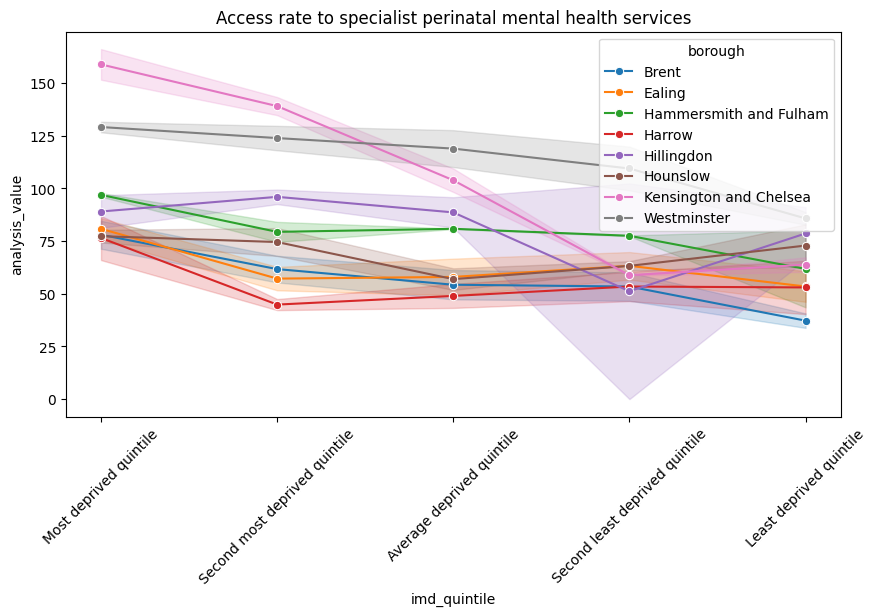

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=subset,
    x="imd_quintile",
    y="analysis_value",
    hue="borough",
    marker="o"
)
plt.title(ind_name)
plt.xticks(rotation=45)
plt.show()

Across all eight North West London boroughs, there is a clear and consistent deprivation gradient for this indicator -'Access rate to specialist perinatal mental health services (94089)' . In every borough, values are lowest in the least deprived quintiles and highest in the most deprived quintiles, indicating systematically worse outcomes or lower access in more deprived areas. The magnitude of the gradient varies by borough, with particularly large absolute gaps observed in inner London boroughs such as Kensington & Chelsea and Westminster, while outer boroughs show smaller but still evident differences. This confirms the presence of structural socio-economic inequality in this outcome across NWL and validates deprivation as a meaningful stratifier for subsequent inequality analysis.